# PRIMO - The Plugging & Abandonment (P&A) Project Optimizer - Project Recommendation

This notebook demonstrates the capabilities of PRIMO in performing P&A projects recommendation only. We follow the workflow in the image below. PRIMO reads input data on wells and their priority scores provided by users, and analyzes it with respect to **USER-DEFINED PREFERENCES** to provide recommendations on the design of impactful and efficient P&A projects. 

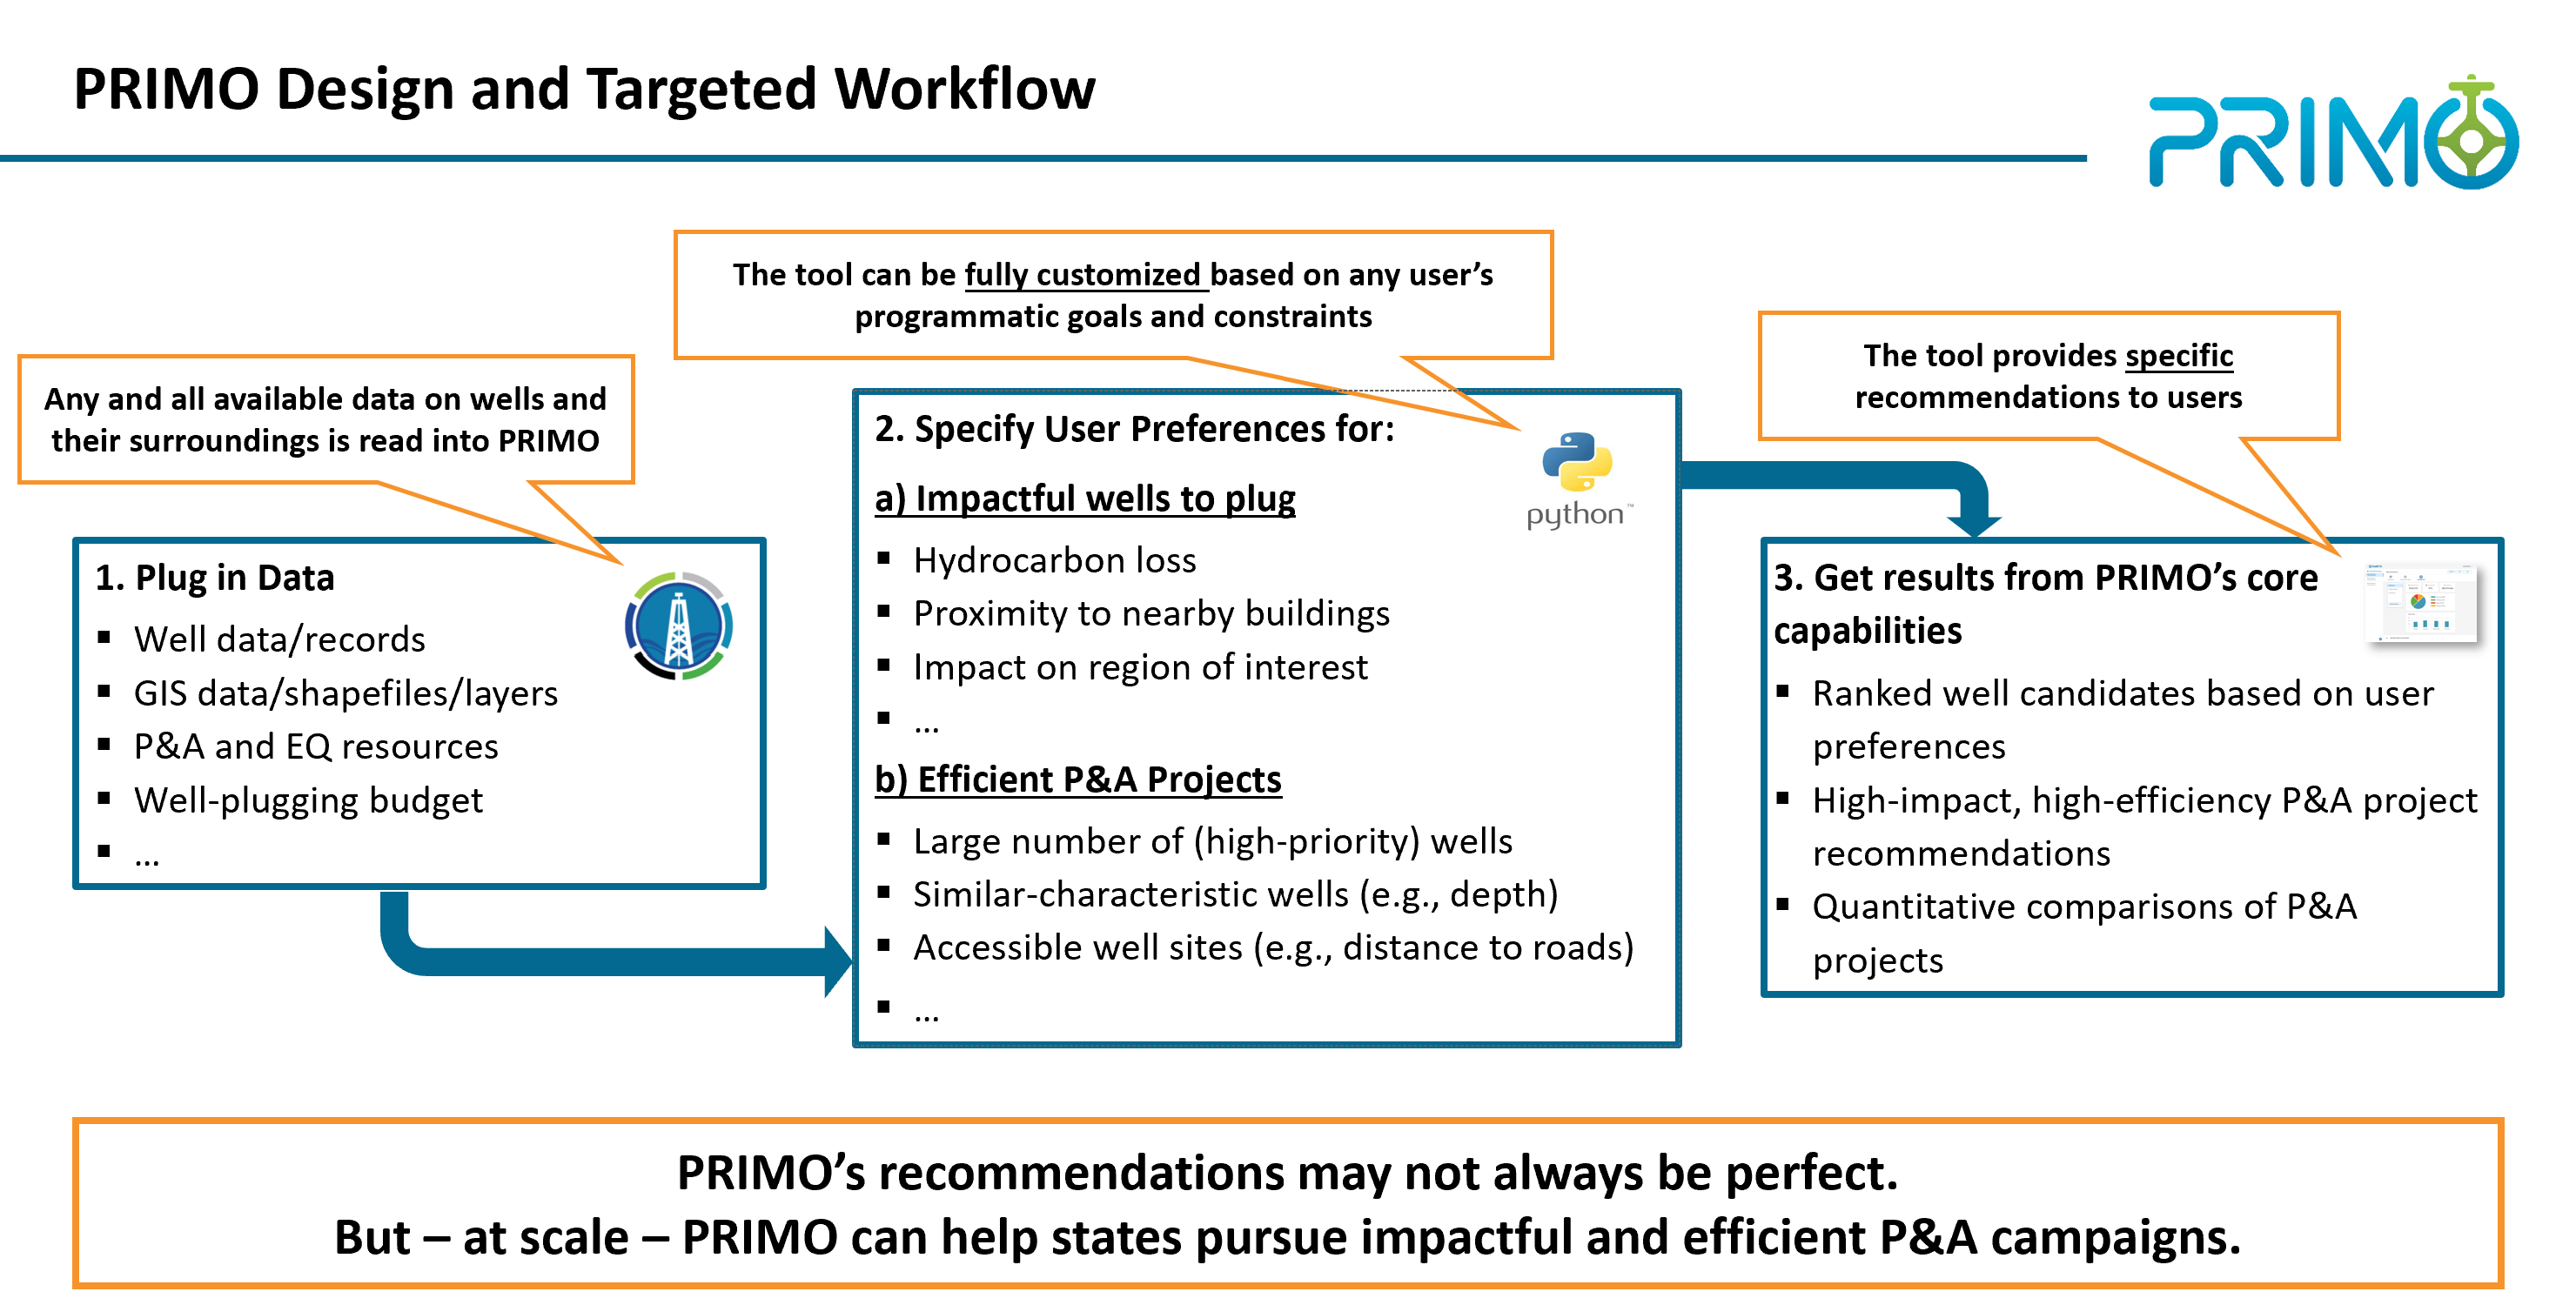

#### **Notice**

This demonstration uses randomized data on a 2-d grid (x and y coordinates), where the x-coordinate represents the latitude, and the y-coordinate represents the longitude of a well. The results are accordingly visualized on scatter plots. For real-life data, PRIMO is designed to process geospatial data containing latitude and longitude information such as shapefiles. As a result, PRIMO has advanced visualization capabilities that uses detailed maps instead of 2-d grids. In addition, PRIMO also has utilities to query data on population density, etc. from external sources, such as U.S. Census.

Overall, this notebook is primarily meant to showcase the workflow and functionality of PRIMO. PRIMO is under active development: please reach out to primo@netl.doe.gov for questions, comments, feedback or feature requests.

### **Import PRIMO Module**

Please follow the download/installation instructions described here (https://primo.readthedocs.io/en/latest/install.html). Note that basic python programming experience/expertise is required to understand this demonstration.

We begin by importing the PRIMO module to use its capabilities. The `demo.visualization` module contains functions for plotting well data on a scatter plot. These functions are written specifically for this demonstration, so they are not available in the `primo` module. Instead, `primo` module has a more advanced functionality called `VisualizeData` for plotting real-life data on detailed maps. Please refer to the documentation for more details on the functionality.

In [1]:
# Imports from installed libraries
from IPython.display import display, Markdown

# Import PRIMO module
import primo
import primo.demo.visualization as visualization


# The following command generates nicely formatted 
# information/warnings/errors while running PRIMO functionalities
primo.setup_logger()

## **P&A Project Recommendation**
The P&A Project Recommendation capability of PRIMO can be utilized independently if the priority scores of wells are provided. This feature allows users to bypass the well ranking process if they already possess information on the priority scores of wells or have pre-prioritized wells.

The main inputs for using the P&A Project Recommendation capability ONLY are 
1. *Choice of efficiency metrics and their associated weights*
2. *Priority score of all the wells* under consideration
3. *Required data to assess the impact and efficiency for all the wells* under consideration.

## Provide Inputs

### **Efficiency Metric Selection**

Ideal P&A projects not only include (many) high-priority wells but also prioritize the efficient use of available resources (e.g., budget, crews, equipment, ...). PRIMO has been designed to quantify the expected IMPACT and EFFICIENCY of recommended P&A candidate projects.

We employ a series of user-defined functions to calculate essential KPIs for each proposed P&A project.

- **Number of Wells**: The more wells a P&A project includes, the the more efficient plugging operations are expected to be - especially if the respective wells are close to each other. Note that upper limits on the number of wells per project may be imposed. Counted as the total number of wells associated with each project.

- **Well Proximities**: This KPI quantifies the "compactness" of any given P&A project. Wells close to each other lead to efficient plugging projects (e.g., reduced mobilization costs/efforts). Defined as the average absolute distance from well locations to the centroid of the project cluster.

- **Well Accessibility - Road Access**: The distance of any well to the closest road access point is used as a measure of well accessibility. The further a well is from any established road, the most costly it is presumed the P&A operation will be. Road construction cost can be significant contributor to project costs and efforts. Measured as the average absolute distance from well locations to their nearest road point. 

- **Well Accessibility - Elevation Change**: This KPI attempts to assess the accessibility of wells by comparing the elevation of the closest road access points to the elevation of the wells contained in a P&A project. If multiple wells in a project are characterized by significant elevation changes, they are presumed to be less accessible which increases P&A costs leading to inefficiencies. Computed as the average absolute elevation delta across all wells within the project group. The elevation delta is referred as the difference in surface elevation of the well and the elevation of the closest road access point. 

- **Well Characteristics - Age Range**: Wells with similar characteristics make for efficient P&A projects. As such, significant differences in well ages within a P&A project can pose challenges to P&A operations. The closer wells are in terms of age, the more efficient a P&A project is presumed to be. This metric Determined by subtracting the minimum age from the maximum age of wells within each P&A project. 

- **Well Characteristics - Depth Range**: Significant differences in well depths within a P&A project can pose challenges to P&A operations. The closer the wells are in terms of depth, the more efficient a P&A project is presumed to be. Calculated as the difference between the maximum and minimum depths of wells within the cluster. 

- **Number of Unique Well Owners**: As the number of (unique) well owners included in a given P&A project increases, so does the effort to manage a given project. Captured by counting the number of distinct company names associated with wells within each project. 

#### Efficiency Factors & Weight Selection Guidelines

Please use the following guidelines when selecting your efficiency factors and their respective weights:
- Use the checkboxes to select preferred efficiency factors and the respective sliders to specify the weight of these 
- The sum of all priorities needs to be 100
- The sum of all sub-priorities within each priority needs to be 100
- If you wish to change the weights after confirming them or getting an error, please re-run the cell in order to get a fresh start

In [2]:
# Define efficiency metrics by creating an instance of EfficiencyMetrics class
eff_metrics = primo.EfficiencyMetrics()

# Set weights for the metrics
# NOTE: This method throws an error if the weights do not add up to 100.
eff_metrics.set_weight(
    primary_metrics={
        "num_wells": 30,
        "num_unique_owners":20,
        "elevation_delta": 20,
        "age_range": 20,
        "depth_range": 10,
    }
)

# Print the updated metrics
print(eff_metrics)

                                          Metric Name  Metric weight
num_wells                             Number of Wells             30
num_unique_owners             Number of Unique Owners             20
elevation_delta                   Elevation Delta [m]             20
age_range                           Age Range [Years]             20
depth_range                          Depth Range [ft]             10
dist_range                     Distance Range [miles]              0
record_completeness               Record Completeness              0
dist_to_road                 Distance to Road [miles]              0
population_density   Total Population Density [#/km2]              0
                                                Total            100


PRIMO provides a widget to specify the weights associated with the efficiency metrics. Uncomment the cells below to specify the weights using the widget.

In [3]:
# # Set weights using the widget
# eff_metrics_widget = eff_metrics.build_widget()
# eff_metrics_widget.display()

In [4]:
# # Update weights from the widget
# eff_metrics.set_weight_from_widget(eff_metrics_widget)

### **Scenario Type Specification**

It is necessary to indicate which PRIMO capability is used when using PRIMO capabilities independently. If the scenario type is not specified, by default, it is assumed that the Well Ranking and Project Recommendation capabilities are both used. 

In [5]:
# Specify PRIMO capabilities being used by creating an instance of ScenarioType class
scenario_type = primo.ScenarioType(well_ranking=False,
    project_recommendation=True,
    project_comparison=False
)

### **Read Well Data**

When providing well data information, please ensure that the priority scores of all wells are included. Additionally, PRIMO can support priority scores in the following patterns:

1. Higher priority score represents higher ranking
2. Lower priority score represents higher ranking

In scenarios where a lower priority score represents a higher ranking, please set `priority_score_reverse` to `True` when constructing the `WellData` class. By default, this value is `False`, indicating that a higher priority score represents a higher ranking.

In [6]:
# Construct an object to store column names
col_names = primo.WellDataColumnNames(
    well_id="API Well Number",
    latitude="y",
    longitude="x",
    operator_name="Operator Name",
    age="Age [Years]",
    depth="Depth [ft]",
    elevation_delta="Elevation Delta [m]",
    ann_gas_production="Gas [Mcf/Year]",
    ann_oil_production="Oil [bbl/Year]",
    additional_columns={"priority_score":"Priority Score",} # specify the name of the column that contains information of well priority scores
)

# Create the WellData object. Ensure the well data input file contains the priority score of each well.
wd = primo.WellData(
    data="Example_Project_Recommendation_data.csv",
    column_names=col_names,
    impact_metrics=None,
    efficiency_metrics=eff_metrics,
    scenario_type=scenario_type,
    priority_score_reverse=False
)

primo: INFO: Reading the well data from the input file.
primo: INFO: Finished reading the well data.
primo: INFO: Beginning to perform preliminary data checks.
primo: INFO: Checking availability and uniqueness of well ids.
primo: INFO: Checking if latitude and longitude information is available for all wells.
primo: INFO: Checking if the operator name is available for all wells.
primo: INFO: Checking if age is available for all wells.
primo: INFO: Checking if depth is available for all wells.
primo: INFO: Checking if ann_gas_production is available for all wells.
primo: INFO: Checking if ann_oil_production is available for all wells.
primo: INFO: Completed processing the essential inputs.
primo: INFO: Finished preliminary processing.
primo: WARNING: Converting negative elevation delta values to positive.


### **Visualization of Wells Population**

PRIMO can distinguish gas and oil wells, and handle them separately for plugging. The user can specify the type of well (`"Gas"` or `"Oil"`) in the input data. Alternatively, the user can provide the annual gas production rate [in Mcf/yr] and the annual oil production rate [in bbl/yr]. Based on their barrels of oil equivalent (BOE) value, PRIMO will categorize each well as either `"Gas"` or `"Oil"`. 

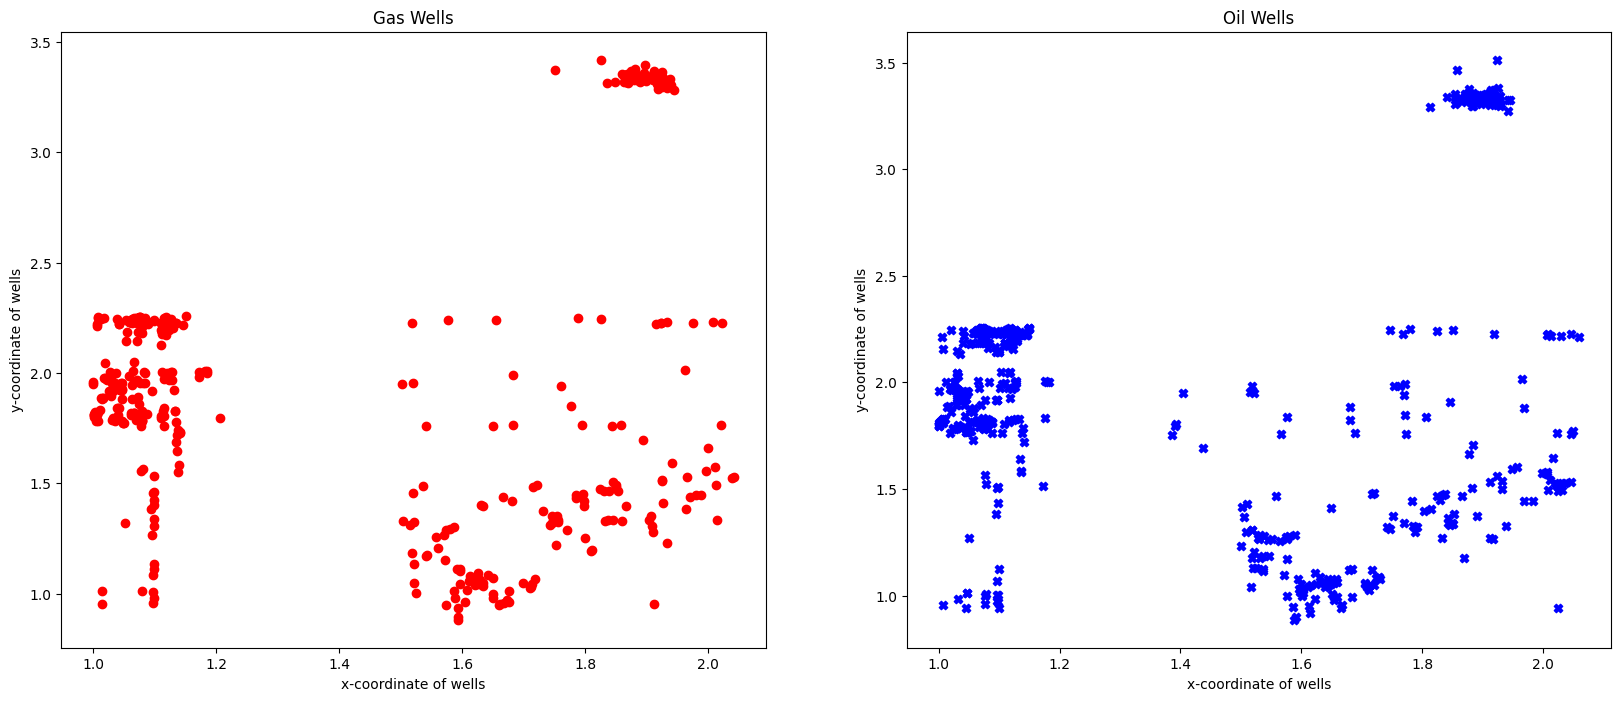

In [7]:
# The property `get_gas_oil_wells` partitions the data set as gas wells
# and oil wells based on their annual BOE production value.
gas_oil_wells = wd.get_gas_oil_wells

gas_wells = gas_oil_wells["gas"]   # WellData object
oil_wells = gas_oil_wells["oil"]   # WellData object

# Visualize wells on an x-y plot.
# NOTE: For real-life data, use `primo.VisualizeData`, with the 
# necessary shapefiles as input, for visualization on detailed maps.
visualization.visualize_gas_oil_wells(gas_wells, oil_wells)

### **Process priority scores**

In [8]:
gas_wells.compute_priority_scores()
oil_wells.compute_priority_scores()

primo: INFO: Completed the calculation of priority scores.
primo: INFO: Completed the calculation of priority scores.


## Budget-Specific P&A Projects Optimization
To determine high-impact, high-efficiency P&A within the available budget, we use an optimization model. The optimization carefully evaluates all possible combinations of wells for plugging projects and helps us select the best campaigns in a data-based, transparent and defensible way.

The goal of the optimization is to seek those P&A projects that are not only impactful but will also lead to the most efficient use of P&A resources. The impact of a P&A project is determined by the priority scores of the wells provided by users. More information on the definition and calculation of the predicted efficiency of a P&A project is provided below.

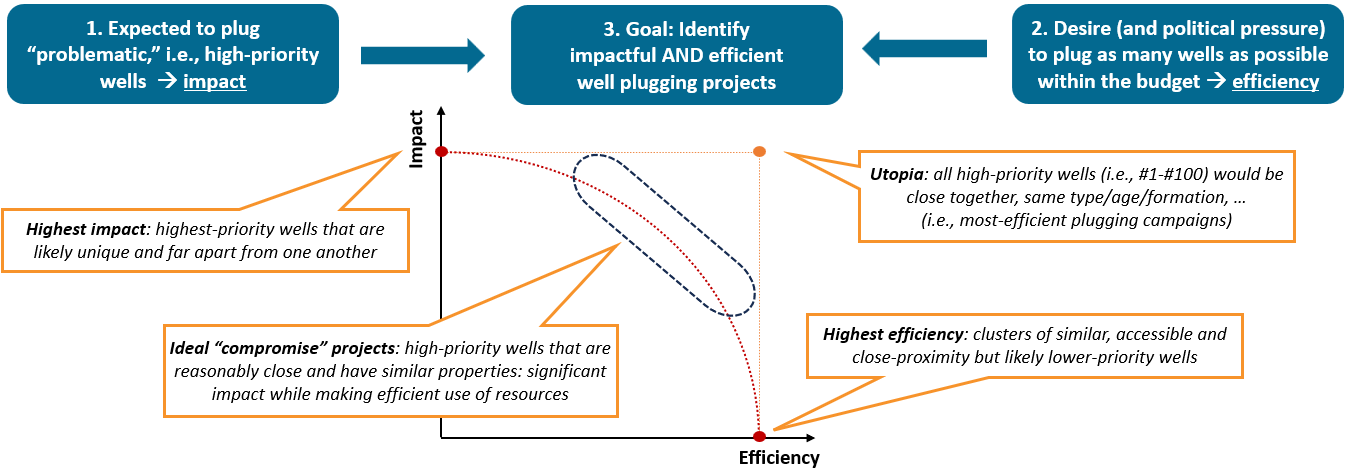

### **State-Wide Program Constraints**

In [9]:
max_wells_per_owner = 1  #
threshold_distance = 10  # [in miles]
gas_budget = 3.21e6      # USD
max_wells_in_project = None

# Mobilization cost
mobilization_cost = {1: 120000, 2: 210000, 3: 280000, 4: 350000}
for n_wells in range(5, len(gas_wells) + 1):
    mobilization_cost[n_wells] = n_wells * 84000

### **Clustering Wells to Identify High-Impact, High-Efficiency P&A Candidate Projects**
At present, wells are clustered based on proximity and similarity in characteristics (e.g. well age) so they can be organized into IMPACTFUL and EFFICIENT P&A projects. To identify groups of wells that would form a promising set for a project, we apply a constrained clustering algorithm.

### **Optimizing for P&A Gas Projects**

primo: INFO: Processing optimization model inputs.
primo: INFO: Clustering Data in OptModelInputs
primo: INFO: Clustering wells using the Agglomerative clustering method.
primo: INFO: Finished processing optimization model inputs.


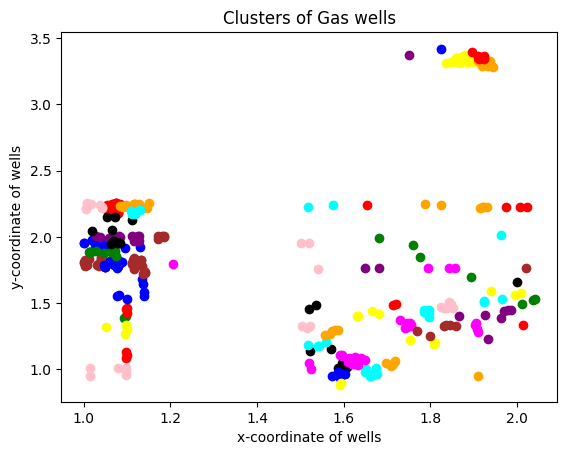

In [10]:
# Set inputs for the optimization models
gas_model_inputs = primo.OptModelInputs(
    well_data=gas_wells,
    total_budget=gas_budget,
    mobilization_cost=mobilization_cost,
    threshold_distance=threshold_distance,
    max_wells_per_owner=max_wells_per_owner,
    max_wells_in_project=max_wells_in_project,
    objective_weight_impact=100, # Weight on Impact Metrics: A value of 100 indicates that the optimization problem is solved by maximizing the impact scores of projects only
)

visualization.visualize_clusters(gas_wells, well_type="Gas")

In [11]:
model = gas_model_inputs.build_optimization_model()
opt_campaign_gas = gas_model_inputs.solve_model(solver="highs")

primo: INFO: Checking budget
primo: INFO: Beginning to construct the optimization model.
primo: INFO: Completed the construction of the optimization model.
Running HiGHS 1.9.0 (git hash: fa40bdf): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e-01, 4e+01]
  Cost   [1e+00, 1e+02]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 3e+00]
Presolving model
381 rows, 1027 cols, 2327 nonzeros  0s
257 rows, 903 cols, 2079 nonzeros  0s
253 rows, 884 cols, 2219 nonzeros  0s
Objective function is integral with scale 1

Solving MIP model with:
   253 rows
   884 cols (882 binary, 1 integer, 1 implied int., 0 continuous)
   2219 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |            Objective Bo

### **RESULT: Summary of PRIMO-Recommended High-Impact, High-Efficiency P&A Gas Projects**

In [12]:
opt_campaign_gas

In [13]:
opt_campaign_gas.display_efficiency_metric_scores()

Project ID,Num Wells Score [0-30],Num Unique Owners Score [0-20],Elevation Delta Score [0-20],Age Range Score [0-20],Depth Range Score [0-10],Efficiency Score [0-100],Accessibility Score [0-20]
2,10.80,0.00,0.64,7.32,1.36,20.12,0.64
4,6.00,0.00,0.88,2.68,4.50,14.06,0.88
6,6.00,0.00,0.00,10.42,4.62,21.05,0.00
11,4.80,5.00,1.76,4.93,5.66,22.15,1.76
28,6.00,0.00,5.68,8.59,1.71,21.98,5.68
31,6.00,0.00,4.48,5.77,5.85,22.10,4.48
32,6.00,0.00,1.44,0.70,6.43,14.57,1.44


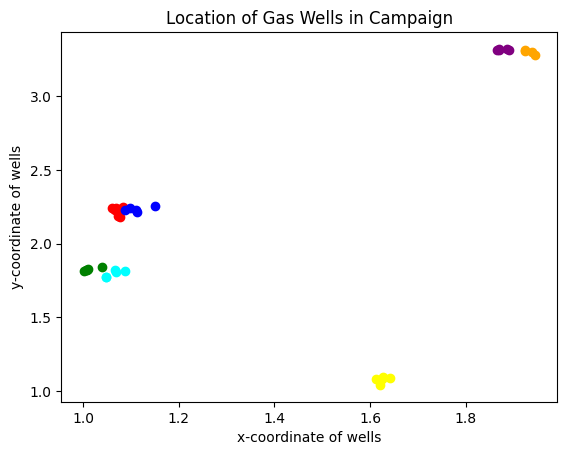

In [14]:
# NOTE: For real-life data use the methods in primo.VisualizeData 
opt_campaign_gas.plot_campaign(title="Location of Gas Wells in Campaign")

In [ ]:
# View details of all wells in a specific project
opt_campaign_gas.projects[11]

Well Rank,API Well Number,Operator Name,y,x,Age [Years],Depth [ft],Priority Score,Priority Score [0-100]
8,41200,Owner 48,3.30,1.94,46,11492,98,98
15,13627,Owner 2,3.31,1.92,40,8482,96,96
88,59266,Owner 250,3.28,1.94,3,5927,81,81
100,84538,Owner 94,3.32,1.92,110,10140,79,79


## Edit existing projects

PRIMO allows users to modify projects manually to satisfy requirements not considered above.

Please use the widgets to select the projects and/or wells:
- Step 1 - Remove Widget: This widget allows you to remove projects and/or wells from the recommended P&A projects.
    - Select P&A projects that should be removed from the recommendations. To confirm your selection, press the "Select Projects to Manually Remove" button. 
    - Select wells that should be removed from the recommended P&A projects. To confirm your selection, press the "Select Wells to Manually Remove" button. 
    - Once you are satisfied with your selections, please press the "Confirm Removal" button to proceed to the next step.
- Step 2 - Add Widget: Use this widget to select wells to be included in the P&A projects. 
    - Select wells using the text box on the left and enter the project in which the well should be included using the text box on the right. If you do not wish to include the well in a specific project, please leave the project text box with its default value, which will appear when you select the well on the left. To confirm your selection, press the "Select Wells to Manually Add" button.
- Step 3 - Lock Widget: This widget is for locking wells and/or projects in the recommended P&A projects during the re-optimization step.
    - Select P&A projects that you are satisfied with and wish to keep. To confirm your selection, press the "Select Projects to Manually Lock" button. 
    - Select wells that should be retained in the recommended P&A projects. To confirm your selection, press the "Select Wells to Manually Lock" button.

Notice:
- If you need to exclude a project or well that has already been selected, please use the "Undo" button associated with the corresponding widget.
- Once you click the "Confirm Removal" button, you will not be able to modify the projects and wells selected for removal. Please re-execute the cell below to restart your selection.
- If you do not want to remove, add, or lock any projects or wells, please leave the corresponding widget blank.
- Selections must be made for each type of well project individually.

#### **Gas wells**

##### Select wells to be included in or excluded from the Recommended P&A Projects 

In [18]:
override_widget_gas = primo.UserSelection(opt_campaign_gas.clusters_dict,gas_model_inputs)
override_widget_gas.display()

'Remove projects/wells'

##### Edit & Evaluate

In [19]:
override_selections_gas = override_widget_gas.return_value()
campaign_gas = primo.OverrideCampaign(
    override_selections=override_selections_gas,
    opt_inputs=gas_model_inputs,
    opt_campaign=opt_campaign_gas.clusters_dict,
    eff_metrics=eff_metrics,
)

violation_info_dict_gas = campaign_gas.violation_info
for msg, df in violation_info_dict_gas.items():
    display(Markdown(msg),df)

Project Status:

'FEASIBLE'

In [20]:
override_campaign_gas = campaign_gas.recalculate()
print(override_campaign_gas)

primo: INFO: Computing scaling factors for efficiency metrics
Optimal campaign has 7 projects and the cost is $3,206,000.

Campaign Summary:

 Project ID  Number of Wells Plugging Cost [$]  Impact Score [0-100]  Efficiency Score [0-100]
          2                9           756,000                 92.33                     20.12
          4                5           420,000                 85.00                     14.06
          6                5           420,000                 91.20                     21.05
         11                4           350,000                 88.50                     22.15
         28                5           420,000                 91.60                     21.98
         31                5           420,000                 93.00                     22.10
         32                5           420,000                 91.20                     14.57


##### Edit & Optimize

Users have the option to re-run the optimization problem in PRIMO, generating new P&A projects based on the previously project edits.

In [21]:
override_dict_gas = campaign_gas.re_optimize_data()
gas_model_inputs.update_cluster(override_selections_gas)

gas_model_inputs.build_optimization_model(override_dict_gas)
opt_campaign_gas = gas_model_inputs.solve_model(solver="highs")

primo: INFO: Checking budget
primo: INFO: Beginning to construct the optimization model.
primo: INFO: Completed the construction of the optimization model.
Running HiGHS 1.9.0 (git hash: fa40bdf): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e-01, 4e+01]
  Cost   [1e+00, 1e+02]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 3e+00]
Presolving model
381 rows, 1027 cols, 2327 nonzeros  0s
257 rows, 903 cols, 2079 nonzeros  0s
253 rows, 884 cols, 2219 nonzeros  0s
Objective function is integral with scale 1

Solving MIP model with:
   253 rows
   884 cols (882 binary, 1 integer, 1 implied int., 0 continuous)
   2219 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |            Objective Bo

In [22]:
reoptimization_capmaign_gas = primo.AssessFeasibility(gas_model_inputs,opt_campaign_gas.clusters_dict)
violation_info_dict_gas_reoptimization = reoptimization_capmaign_gas.violation_info()
for msg, df in violation_info_dict_gas_reoptimization.items():
    display(Markdown(msg),df)
opt_campaign_gas

Project Status:

'FEASIBLE'

If necessary, please execute the cell to generate the widgets and make a new edit based on the new recommended P&A projects.

## Saving PRIMO Results

We save the gas well and oil well projects in an excel file for each run. The default file name for the run is "Primo_Projects.xlsx".

In [23]:
output_file_path = "Primo_Projects.xlsx"
campaigns = [opt_campaign_gas]
campaign_labels = ["Gas"]
primo.export_data_to_excel(
    output_file_path=output_file_path,
    campaigns=campaigns,
    campaign_categories=campaign_labels,
)